## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the biological question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.stats import hypergeom
import networkx as nx
RECIPE_ID='04-reactome-enrichment'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'airway': '5440d5e8dc3a3da15735ad2592cf908bcfc7f4bdadc89b1404aa48d728bdeaab', 'reactome': '7ac8938695d294fb8c8b56072fca97d7420fafb2f436c6437a8ef72b7c3bfbe9'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['airway', 'reactome']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def validate_counts(counts, metadata):
    if not counts.index.is_unique or not counts.columns.is_unique:
        raise ValueError("Gene and sample identifiers must be unique")
    if not metadata.index.is_unique or list(counts.columns) != list(metadata.index):
        raise ValueError("Sample columns must match metadata order exactly")
    values = counts.to_numpy()
    if not np.isfinite(values).all() or (values < 0).any() or not np.equal(values,np.floor(values)).all():
        raise ValueError("Counts must be finite nonnegative integers")
    if (values.sum(axis=0) == 0).any():
        raise ValueError("A sample has no reads")
    if set(metadata.condition) != {"control","treated"}:
        raise ValueError("Expected control and treated conditions")
    for donor, rows in metadata.groupby("donor", sort=True):
        if len(rows) != 2 or set(rows.condition) != {"control","treated"}:
            raise ValueError("Each donor needs one control and one treated sample: " + str(donor))

print("Method ready: validate_counts")


Method ready: validate_counts


In [4]:
def normalize_counts(counts, min_count=10, min_samples=4):
    values = counts.to_numpy(dtype=float)
    keep = (values >= min_count).sum(axis=1) >= min_samples
    filtered = counts.loc[keep].astype(float)
    positive = (filtered.to_numpy() > 0).all(axis=1)
    if positive.sum() == 0:
        raise ValueError("Median-ratio method needs genes positive in every sample")
    reference_values = filtered.to_numpy()[positive]
    geometric_means = np.exp(np.log(reference_values).mean(axis=1))
    factors = np.median(reference_values / geometric_means[:,None], axis=0)
    if not np.isfinite(factors).all() or (factors <= 0).any():
        raise ValueError("Invalid size factors")
    factors /= np.exp(np.log(factors).mean())
    normalized = filtered / factors
    return filtered, pd.Series(factors,index=counts.columns,name="size_factor"), normalized

print("Method ready: normalize_counts")


Method ready: normalize_counts


In [5]:
def paired_response(log_counts, metadata, min_effect=1.0, min_consistent=3):
    differences = {}
    for donor, rows in metadata.groupby("donor",sort=True):
        control = rows.index[rows.condition == "control"][0]
        treated = rows.index[rows.condition == "treated"][0]
        differences[donor] = log_counts[treated] - log_counts[control]
    differences = pd.DataFrame(differences)
    response = pd.DataFrame(dict(mean_log2_change=differences.mean(axis=1),
                                 positive_pairs=(differences>0).sum(axis=1),
                                 negative_pairs=(differences<0).sum(axis=1)))
    response["direction"] = "other"
    response.loc[(response.mean_log2_change>=min_effect)&(response.positive_pairs>=min_consistent),"direction"]="up"
    response.loc[(response.mean_log2_change<=-min_effect)&(response.negative_pairs>=min_consistent),"direction"]="down"
    return differences, response

print("Method ready: paired_response")


Method ready: paired_response


In [6]:
def bh_adjust(pvalues):
    p = np.asarray(pvalues,dtype=float)
    if not len(p):
        return p.copy()
    if not np.isfinite(p).all() or (p<0).any() or (p>1).any():
        raise ValueError("p-values must be finite and in [0,1]")
    order = np.argsort(p,kind="stable")
    adjusted = np.minimum.accumulate((p[order]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
    result = np.empty_like(p); result[order] = np.minimum(adjusted,1)
    return result

print("Method ready: bh_adjust")


Method ready: bh_adjust


In [7]:
def overrepresentation(up, down, expressed, pathways, min_size=10, max_size=500):
    annotated = set().union(*(set(row["genes"]) for row in pathways)) if pathways else set()
    background = set(expressed) & annotated
    columns = ["direction","pathway","name","background_size","query_size","term_size","overlap","pvalue","genes","qvalue"]
    rows = []
    for direction, supplied in (("up",up),("down",down)):
        query = set(supplied) & background
        for term in pathways:
            members = set(term["genes"]) & background
            if not min_size <= len(members) <= max_size:
                continue
            hits = sorted(query & members)
            p = float(hypergeom.sf(len(hits)-1,len(background),len(members),len(query))) if query else 1.0
            rows.append(dict(direction=direction,pathway=term["id"],name=term["name"],
                background_size=len(background),query_size=len(query),term_size=len(members),
                overlap=len(hits),pvalue=p,genes=";".join(hits)))
    result = pd.DataFrame(rows)
    if len(result):
        result["qvalue"] = bh_adjust(result.pvalue.to_numpy())
        result = result.sort_values(["qvalue","pvalue","pathway","direction"],kind="stable")
    else:
        result = pd.DataFrame(columns=columns)
    return background,result

print("Method ready: overrepresentation")


Method ready: overrepresentation


## Steps

### 1. Rebuild a self-contained candidate analysis

This notebook contains the complete airway matrix and runs without lesson 03 or its output files. The original experiment and donor pairing are unchanged. Start by auditing the eight sample identifiers. An input gene list without its selection rule and measured universe is not enough for a defensible enrichment analysis.

In [8]:
airway = snapshot("airway")
counts = pd.DataFrame(airway["counts"], index=airway["genes"], columns=airway["samples"])
metadata = pd.DataFrame(airway["metadata"]).set_index("sample").loc[counts.columns]
validate_counts(counts, metadata)
print("Complete count matrix:", counts.shape)
def display_scroll_table(frame):
    # Keep identifiers and numeric values intact on narrow device screens.
    table = frame.to_html(border=0, classes="vibeit-scroll-table")
    style = """<style>
    table.vibeit-scroll-table {table-layout:auto !important;width:max-content !important;max-width:none !important;}
    table.vibeit-scroll-table th, table.vibeit-scroll-table td {
      white-space:nowrap !important;word-break:normal !important;padding:6px 8px;}
    </style>"""
    display(HTML(style+'<div style="max-width:100%;overflow-x:auto;-webkit-overflow-scrolling:touch">'+table+'</div>'))
display_scroll_table(metadata)
display_scroll_table(counts.iloc[:6])


Complete count matrix: (63677, 8)


,condition,donor,geo
SRR1039508,control,N61311,GSM1275862
SRR1039509,treated,N61311,GSM1275863
SRR1039512,control,N052611,GSM1275866
SRR1039513,treated,N052611,GSM1275867
SRR1039516,control,N080611,GSM1275870
SRR1039517,treated,N080611,GSM1275871
SRR1039520,control,N061011,GSM1275874
SRR1039521,treated,N061011,GSM1275875


,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ENSG00000000003,679,448,873,408,1138,1047,770,572
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,467,515,621,365,587,799,417,508
ENSG00000000457,260,211,263,164,245,331,233,229
ENSG00000000460,60,55,40,35,78,63,76,60
ENSG00000000938,0,0,2,0,1,0,0,0


### 2. Normalize before selecting candidates

Apply the same count filter and median-ratio method as lesson 03. Candidate selection must be based on the measurements, before looking at the pathways. Selecting genes because they belong to a pathway and then testing that same pathway creates circular evidence.

In [9]:
MIN_COUNT, MIN_SAMPLES = 10, 4
filtered, size_factors, normalized = normalize_counts(counts, MIN_COUNT, MIN_SAMPLES)
log_counts = np.log2(normalized + 1)
print("Retained genes:", len(filtered), "of", len(counts))
print("Genes positive in every sample:", int((filtered > 0).all(axis=1).sum()))
display(size_factors.to_frame())


Retained genes: 16139 of 63677
Genes positive in every sample: 16072


,size_factor
SRR1039508,1.019000
SRR1039509,0.893462
SRR1039512,1.170560
SRR1039513,0.666422
SRR1039516,1.171945
SRR1039517,1.395186
SRR1039520,0.913847
SRR1039521,0.942312


### 3. Make the screening rule explicit

Up candidates have a mean paired log2 change ≥1 and at least three positive donor differences; down candidates have a mean ≤−1 and at least three negative differences. These are effect-based response candidates, not statistically tested DEGs. The scatter plot shows both retained and unselected genes so the threshold stays visible.

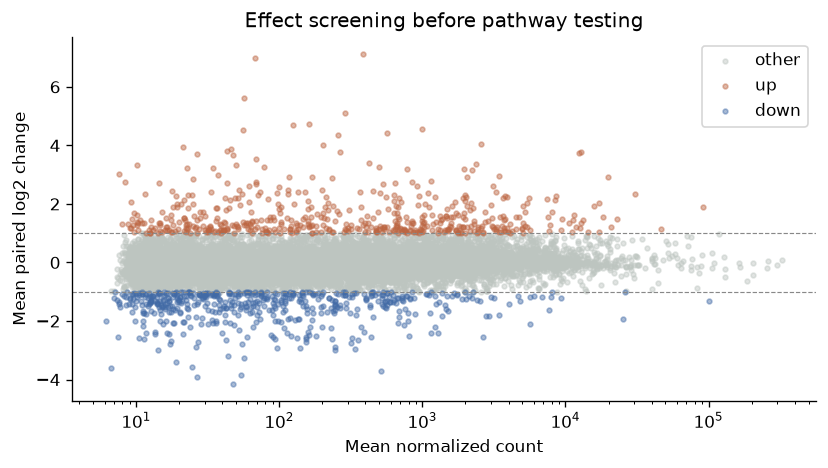

Up / down / retained: 527 529 16139


In [10]:
paired_changes,response=paired_response(log_counts,metadata,min_effect=1,min_consistent=3)
up=set(response.index[response.direction=="up"])
down=set(response.index[response.direction=="down"])
fig,ax=plt.subplots(figsize=(7,4))
for direction,color in [("other","#bdc5c0"),("up","#bc6541"),("down","#416aa6")]:
    selected=response.direction==direction
    ax.scatter(normalized.mean(axis=1)[selected],response.mean_log2_change[selected],s=8,alpha=.45,color=color,label=direction)
ax.set_xscale("log");ax.axhline(1,color="#888",ls="--",lw=.7);ax.axhline(-1,color="#888",ls="--",lw=.7)
ax.set(xlabel="Mean normalized count",ylabel="Mean paired log2 change",title="Effect screening before pathway testing")
ax.legend();plt.tight_layout();plt.show()
print("Up / down / retained:",len(up),len(down),len(filtered))


### 4. Define the gene universe from actual measurements

The frozen Reactome mapping contains human Ensembl genes and lowest-level pathway memberships. Intersect measured, filtered genes with genes covered by these annotations. Report unmapped candidates. Do not use every human gene as the background for a filtered experiment. Our term-size rule is 10–500 members within this background, chosen before viewing results.

In [11]:
reactome=snapshot("reactome")
pathways=reactome["pathways"]
annotated=set().union(*(set(term["genes"]) for term in pathways))
background=set(filtered.index)&annotated
print("Reactome version:",reactome["version"])
audit=pd.DataFrame([dict(stage="Measured",genes=len(counts)),dict(stage="Expression filter",genes=len(filtered)),
 dict(stage="Annotated background",genes=len(background)),dict(stage="Up candidates mapped",genes=len(up&background)),
 dict(stage="Down candidates mapped",genes=len(down&background))])
display(audit)
print("Unmapped up / down candidates:",len(up-background),len(down-background))


Reactome version: 97


,stage,genes
0,Measured,63677
1,Expression filter,16139
2,Annotated background,7980
3,Up candidates mapped,288
4,Down candidates mapped,272


Unmapped up / down candidates: 239 257


### 5. Test every eligible term and correct the complete family

For N background genes, K term members, n candidates and k overlapping genes, the one-sided p-value is P(X≥k) = `hypergeom.sf(k−1,N,K,n)`. Include terms with zero overlap (p=1), then apply BH across **both directions together**. A q-value is not the probability that a pathway is active. Expression-based selection and related pathway memberships also constrain biological interpretation.

In [12]:
background,enrichment=overrepresentation(up,down,filtered.index,pathways,min_size=10,max_size=500)
print("Complete test family:",len(enrichment))
print("Terms with q < 0.05:",int((enrichment.qvalue<.05).sum()) if len(enrichment) else 0)
display(enrichment.drop(columns="genes").head(12))


Complete test family: 2086
Terms with q < 0.05: 5


,direction,pathway,name,background_size,query_size,term_size,overlap,pvalue,qvalue
1436,down,R-HSA-418594,G alpha (i) signalling events,7980,272,85,13,0.000005,0.009649
661,up,R-HSA-71384,Ethanol oxidation,7980,288,10,5,0.000013,0.009649
1427,down,R-HSA-416476,G alpha (q) signalling events,7980,272,67,11,0.000014,0.009649
1641,down,R-HSA-6785807,Interleukin-4 and Interleukin-13 signaling,7980,272,74,11,0.000037,0.019049
1437,down,R-HSA-418597,G alpha (z) signalling events,7980,272,33,7,0.000099,0.041178
828,up,R-HSA-9615017,FOXO-mediated transcription of oxidative stres...,7980,288,19,5,0.000453,0.123393
348,up,R-HSA-381426,Regulation of Insulin-like Growth Factor (IGF)...,7980,288,79,10,0.000509,0.123393
1594,down,R-HSA-5669034,TNFs bind their physiological receptors,7980,272,12,4,0.000526,0.123393
1376,down,R-HSA-375276,Peptide ligand-binding receptors,7980,272,31,6,0.000532,0.123393
292,up,R-HSA-3000157,Laminin interactions,7980,288,30,6,0.000599,0.124920


### 6. Read the enrichment bubble plot

Show at most twelve nonzero-overlap terms, ordered by q then p. Bubble area encodes overlap count; x is overlap/query size; color is −log10(q). Labels remain descriptive even if no q-value meets 0.05. A ranked plot always has a top row, so ranking alone is not significance.

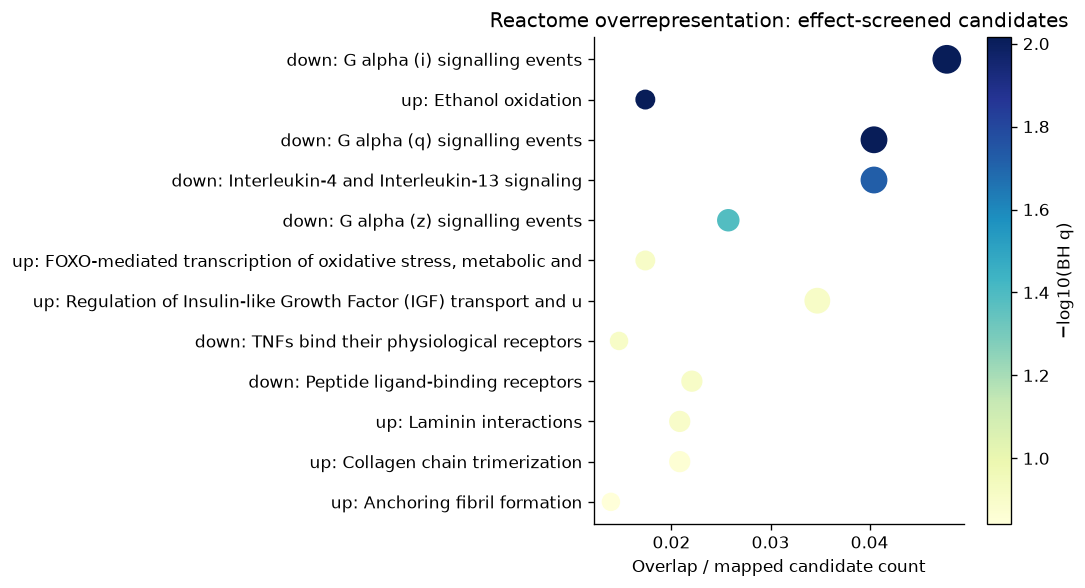

In [13]:
plot_terms=enrichment.loc[enrichment.overlap>0].head(12).copy() if len(enrichment) else enrichment.copy()
fig,ax=plt.subplots(figsize=(9,5))
if len(plot_terms):
    colors=-np.log10(plot_terms.qvalue.clip(lower=1e-300))
    dots=ax.scatter(plot_terms.overlap/plot_terms.query_size,np.arange(len(plot_terms)),
        s=30+18*plot_terms.overlap,c=colors,cmap="YlGnBu")
    names=[r.direction+": "+r.name[:62] for r in plot_terms.itertuples()]
    ax.set(yticks=range(len(names)),yticklabels=names);ax.invert_yaxis()
    fig.colorbar(dots,ax=ax,label="−log10(BH q)")
else:
    ax.text(.5,.5,"No eligible terms with overlapping candidates",ha="center",va="center",transform=ax.transAxes)
ax.set(xlabel="Overlap / mapped candidate count",title="Reactome overrepresentation: effect-screened candidates")
plt.tight_layout();plt.show()


### 7. Inspect redundant pathways through shared genes

Related pathways can share much of their evidence. Use the twelve displayed terms to compute candidate-overlap Jaccard similarity: intersection/union. This graph describes redundancy in the displayed results, not protein interactions. Edges require Jaccard ≥0.2; node color identifies the direction of the candidate set.

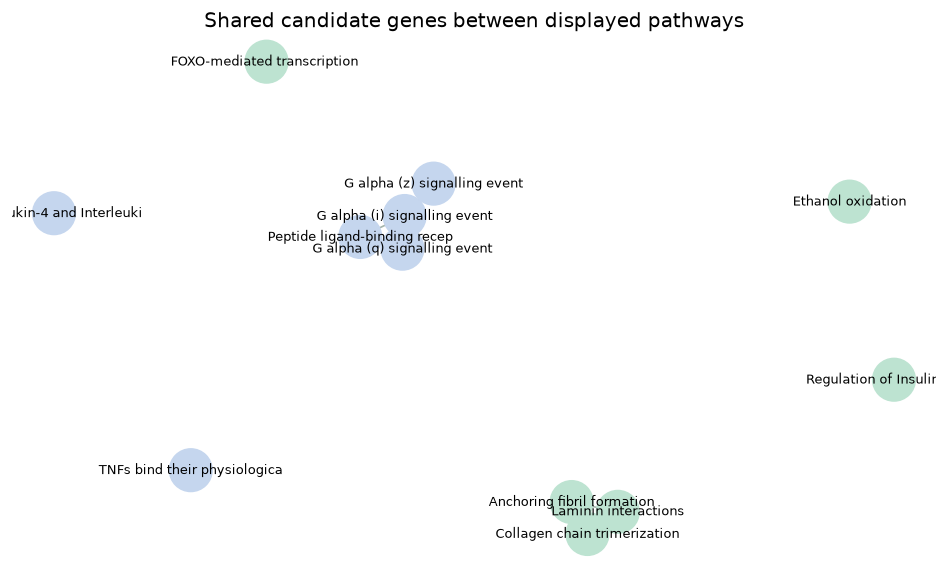

In [14]:
term_graph=nx.Graph()
sets={}
for r in plot_terms.itertuples():
    key=r.direction+":"+r.pathway;sets[key]=set(r.genes.split(";"))
    term_graph.add_node(key,label=r.name[:28],direction=r.direction)
keys=list(sets)
for i,x in enumerate(keys):
    for y in keys[i+1:]:
        similarity=len(sets[x]&sets[y])/len(sets[x]|sets[y]) if sets[x]|sets[y] else 0
        if similarity>=.2:term_graph.add_edge(x,y,jaccard=similarity)
fig,ax=plt.subplots(figsize=(8,5))
if term_graph:
    pos=nx.spring_layout(term_graph,seed=42)
    nx.draw_networkx(term_graph,pos,ax=ax,labels=nx.get_node_attributes(term_graph,"label"),
        node_color=["#bde3d1" if term_graph.nodes[k]["direction"]=="up" else "#c5d6ee" for k in term_graph],
        node_size=650,font_size=8,edge_color="#a4b4ac")
else:ax.text(.5,.5,"No terms to compare",ha="center",transform=ax.transAxes)
ax.set_title("Shared candidate genes between displayed pathways");ax.axis("off")
plt.tight_layout();plt.show()


### 8. Export all tests, including unremarkable results

The export contains all eligible terms in both directions, not only the plotted or significant rows. Include background identifiers and candidate-selection measurements. If the candidate set is empty, every tested p-value is one; an empty universe or missing annotation is an analysis limitation to report, not an invitation to change the background until a desired result appears.

In [15]:
if len(enrichment):
    assert enrichment.qvalue.between(0,1).all()
    assert (enrichment.qvalue+1e-15>=enrichment.pvalue).all()
    assert (enrichment.overlap<=enrichment.term_size).all()
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
enrichment.to_csv(OUTPUT_DIR/"reactome-all-tests.csv",index=False)
response.to_csv(OUTPUT_DIR/"response-screen.csv")
pd.Series(sorted(background),name="ensembl_gene").to_csv(OUTPUT_DIR/"background.csv",index=False)
audit.to_csv(OUTPUT_DIR/"universe-audit.csv",index=False)
print("Checks passed; full background and test family exported")


Checks passed; full background and test family exported


## Exercises and reference explanation

1. What are N, K, n and k for the first result row? Why is every tested pathway included in BH?
2. Set min_effect to 2 and repeat the full test family, including zero-overlap terms.

**Reference explanation.** N is the annotated measured background, K the term size within it, n the mapped directional candidate count and k the overlap. Correcting only interesting terms understates multiplicity. Stronger screening changes the question as well as the candidate set.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Add the N/K/n/k values to the displayed table and validate one hypergeometric tail by summing the probability mass function. Preserve the measured background and both-direction BH family.

**Prompt 2**

> Add a sensitivity comparison using all measured annotated genes versus expression-filtered annotated genes. Label the former as a different universe and explain why its p-values answer a different question.

**Human acceptance.** Check every candidate belongs to the chosen universe, zero overlap gives p=1, empty candidate sets give p=q=1, q stays in [0,1], and all eligible tests remain in the export.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [16]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://reactome.org/ContentService/data/database/version',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [airway read counts](https://raw.githubusercontent.com/bioconductor-source/airway/596678815f4ade04a9711997150949b9782aeddc/data/airway.RData) — LGPL (airway package); original experiment: Himes et al. 2014; retrieved 2026-10-09. SHA-256 `98d05e82867ae4bed92295eb8863ab6c1aa694876f2b29b455c30a559f801cd0`.
  rdata 1.1.0: assays.data.listData['counts'], rowRanges.partitioning.NAMES, colData; no scaling or gene subsetting

- [Reactome human Ensembl pathway mapping](https://reactome.org/download/current/Ensembl2Reactome.txt) — CC0 1.0; retrieved 2026-10-09. SHA-256 `34852dc2ac258a851bad914708c0045a636161dbbeca604f04343174cca8d7fb`.
  Lowest-level pathways; Homo sapiens; retain genes present in the complete airway matrix; deduplicate memberships


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.